In [12]:
!pip install Sastrawi -q
!pip install google-play-scraper sastrawi -q

# 1. Manipulasi Data & Operasi Sistem Dasar
import pandas as pd
import os
import csv
import requests
from io import StringIO

# 2. Pembersihan Teks (Reguler Expression & String)
import re
import string

# 3. Visualisasi Data (Grafik)
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Modul Scraping Google Play Store
from google_play_scraper import Sort, reviews

# 5. Natural Language Processing (NLTK)
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Mengunduh kamus bawaan NLTK tanpa menampilkan log panjang (quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

# 6. Natural Language Processing (Sastrawi)
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

print("✅ Library Bersih dan Siap Digunakan!")


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ Library Bersih dan Siap Digunakan!



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
result,_ = reviews(
    'com.gojek.app',
    lang='id',
    country='id',
    sort=Sort.MOST_RELEVANT,
    count=200000,
    filter_score_with=None
)

df = pd.DataFrame(result)
df = df[['content', 'score']]
df.rename(columns={'content': 'ulasan'}, inplace=True)
df.drop_duplicates(subset=['ulasan'], inplace=True)

print(f"✅ Scraping Selesai! Berhasil mengambil {len(df)} ulasan unik.")

✅ Scraping Selesai! Berhasil mengambil 197938 ulasan unik.


##Preprocessing

In [14]:
print(f"1. Jumlah data mentah awal: {len(df)}")

df = df.dropna(subset=['ulasan'])

df = df.drop_duplicates(subset=['ulasan'], keep='first')
df = df.reset_index(drop=True)

print(f"2. Jumlah data setelah hapus duplikat & NaN: {len(df)}")

1. Jumlah data mentah awal: 197938
2. Jumlah data setelah hapus duplikat & NaN: 197938


In [15]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text)
    text = re.sub(r'#[A-Za-z0-9]+', '', text)
    text = re.sub(r'RT[\s]', '', text)
    text = re.sub(r"http\S+", '', text)
    text = re.sub(r'[0-9]+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = text.replace('\n', ' ')
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip(' ')
    return text

def casefoldingText(text):
    return text.lower()

slangwords = {"ga": "tidak", "gak": "tidak", "gk": "tidak", "g": "tidak",
    "nggk": "tidak", "nggak": "tidak", "ngk": "tidak", "gx": "tidak",
    "kagak": "tidak", "kaga": "tidak", "ndak": "tidak", "gbsa": "tidak bisa",
    "gabisa": "tidak bisa", "gbs": "tidak bisa", "blm": "belum", "blom": "belum",
    "belom": "belum", "jgn": "jangan", "jngn": "jangan", "knp": "kenapa",
    "knpa": "kenapa", "napa": "kenapa", "ngapain": "mengapa", "gmn": "bagaimana",
    "gmna": "bagaimana", "gimana": "bagaimana", "gmana": "bagaimana",
    "gimna": "bagaimana", "ap": "apa", "apaan": "apa", "kpn": "kapan", "brp": "berapa",

    # Kelompok Pronomina dan Sapaan
    "gw": "saya", "gua": "saya", "guwe": "saya", "q": "saya", "aq": "saya",
    "sy": "saya", "sya": "saya", "lu": "kamu", "lo": "kamu", "elu": "kamu",
    "klen": "kalian", "kalyan": "kalian", "org": "orang", "orng": "orang",
    "min": "admin", "mimin": "admin", "cs": "layanan pelanggan",
    "tmen": "teman", "tmn": "teman", "ortu": "orang tua",

    # Kelompok Konjungsi, Preposisi, dan Partikel
    "yg": "yang", "yng": "yang", "d": "di", "k": "ke", "dr": "dari",
    "dri": "dari", "dlm": "dalam", "dgn": "dengan", "dg": "dengan",
    "dngan": "dengan", "dngn": "dengan", "sm": "sama", "sma": "sama",
    "am": "sama", "pdhl": "padahal", "pdhal": "padahal", "padhl": "padahal",
    "krn": "karena", "krna": "karena", "karna": "karena", "klo": "kalau",
    "klw": "kalau", "kl": "kalau", "klu": "kalau", "kalok": "kalau",
    "kalo": "kalau", "tp": "tapi", "tpi": "tapi", "tpii": "tapi",
    "jd": "jadi", "jdi": "jadi", "trs": "terus", "trus": "terus",
    "tros": "terus", "utuk": "untuk", "utk": "untuk", "buat": "untuk",
    "bwt": "untuk", "ny": "nya", "nyaa": "nya", "sdh": "sudah",
    "udh": "sudah", "dh": "sudah", "uda": "sudah", "udah": "sudah",
    "aja": "saja", "aj": "saja", "ajh": "saja", "aje": "saja",
    "mulu": "melulu", "noh": "itu",

    # Kelompok Adjektiva dan Adverbia
    "bgt": "sekali", "bngt": "sekali", "bnget": "sekali", "bangett": "sekali",
    "banget": "sekali", "bet": "sekali", "bat": "sekali", "bener": "benar",
    "bner": "benar", "cpt": "cepat", "cepet": "cepat", "cepetan": "cepat",
    "lelet": "lambat", "lemot": "lambat", "lemooot": "lambat", "keong": "lambat",
    "lma": "lama", "lamaa": "lama", "kzl": "kesal", "kesel": "kesal",
    "ancur": "hancur", "hancur": "hancur", "deket": "dekat", "dkt": "dekat",
    "gaje": "tidak jelas", "gajelas": "tidak jelas", "cmn": "cuma",
    "cuman": "cuma", "coman": "cuma", "lbih": "lebih", "lbh": "lebih",
    "bnyk": "banyak", "bnyak": "banyak", "byk": "banyak", "trllu": "terlalu",
    "parah": "sangat buruk", "paraaaahhh": "sangat buruk", "gercep": "gerak cepat",

    # Kelompok Verba Tindakan dan Serapan Asing Termutasi
    "pesen": "pesan", "mesen": "pesan", "psn": "pesan", "dpt": "dapat",
    "dapet": "dapat", "dptnya": "dapat", "donlod": "unduh", "dowload": "unduh",
    "donwload": "unduh", "dl": "unduh", "apus": "hapus", "hapus": "hapus",
    "nyari": "mencari", "nyariin": "mencari", "nyari2": "mencari",
    "nunggu": "menunggu", "nungguin": "menunggu", "ngabarin": "mengabari",
    "nganter": "mengantar", "ngantar": "mengantar", "diantr": "diantar",
    "nyampe": "sampai", "nyampek": "sampai", "smpai": "sampai",
    "smpe": "sampai", "mpe": "sampai", "bkin": "buat", "bikin": "buat",
    "ngasi": "memberi", "ngasih": "memberi", "ksih": "beri", "ksh": "beri",
    "nambah": "menambah", "nmbah": "menambah", "ngegas": "marah",
    "nyantol": "tersambung", "bales": "balas", "nelfon": "telepon",
    "telpon": "telepon", "tlfn": "telepon", "tlpn": "telepon", "tlp": "telepon",
    "tf": "transfer", "tranfer": "transfer", "pake": "pakai", "pke": "pakai",
    "pakek": "pakai", "pkai": "pakai", "dibukak": "dibuka",

    # Kelompok Nomina dan Istilah Teknis
    "app": "aplikasi", "apk": "aplikasi", "apl": "aplikasi", "aplikasih": "aplikasi",
    "vocer": "voucer", "vocher": "voucer", "vchr": "voucer",
    "ongkir": "ongkos kirim", "onkir": "ongkos kirim", "hrga": "harga",
    "hrg": "harga", "rb": "ribu", "k": "ribu", "mnt": "menit", "jm": "jam",
    "kndaraan": "kendaraan", "t4": "tempat", "mknan": "makanan",
    "nasdang": "nasi padang", "ojol": "ojek daring",

    # Kelompok Kata Kasar, Ekspresi, dan Emosi
    "anjir": "sialan", "anjeng": "sialan", "anjing": "sialan", "anj": "sialan",
    "anjng": "sialan", "anjg": "sialan", "taik": "kotoran", "taek": "kotoran",
    "tai": "kotoran", "bangsat": "brengsek", "bangsattt": "brengsek",
    "gblk": "bodoh", "goblok": "bodoh", "tolol": "bodoh", "bego": "bodoh",
    "ngentot": "sialan", "babi": "sialan", "kampret": "sialan",
    "sialan": "sialan", "hadeh": "aduh", "hadeehh": "aduh", "haduh": "aduh"
}


def fix_slangwords(text):
    words = text.split()
    fixed_words = [slangwords.get(word, word) for word in words]
    return ' '.join(fixed_words)

def tokenizingText(text):
    return word_tokenize(text)

def filteringText(text):
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords.update(set(stopwords.words('english')))
    listStopwords.update([
        'yg', 'dengan', 'saya', 'ini', 'di', 'untuk', 'saja', 'dan', 'ada', 'juga', 'dah', 'bbm',
        'otp', 'lagi', 'lebih', 'terus', 'tolong', 'masih', 'sama', 'aja', 'aplikasi', 'pertamina',
        'udah', 'seperti', 'apa', 'game', 'gitu', 'sebagai', 'mau', 'buat', 'akan', 'masalah',
        'kok', 'harusnya', 'sudah', 'tp', 'atau', 'login', 'register', 'update', 'akun', 'server',
        'spbu', 'pakai', 'aplikasinya', 'ketika', 'langsung', 'kadang', 'menurut', 'masuk', 'pengguna',
        'buka', 'coba', 'bantu', 'baru', 'selalu', 'banyak', 'kali', 'mudah', 'dari', 'oke',
        'bukan', 'ingin', 'terlihat', 'pada', 'kita', 'sistem', 'kenapa',
        'yang', 'gue', 'nya', 'itu', 'ternyata', 'ya', 'yaa', 'kode',
        'jadi', 'daftar', 'pa', 'apk', 'app', 'hp', 'gaa', 'ngaa', 'bayar', 'bisa', 'ga',
        'download', 'bikin', 'banget', 'ulang', 'beli','padahal','jg','kan',
        'sih','gimana','gamenya','bagu','sya','g','y','link','moga'
    ])
    return [txt for txt in text if txt not in listStopwords]

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemmingText(text):
    joined_text = ' '.join(text)
    return stemmer.stem(joined_text)

def toSentence(list_words):
    return ' '.join(word for word in list_words)

print("✅ Seluruh fungsi preprocessing berhasil didefinisikan!")

✅ Seluruh fungsi preprocessing berhasil didefinisikan!


In [16]:
print("1. Melakukan Cleaning & Casefolding...")
df['text_clean'] = df['ulasan'].apply(cleaningText)
df['text_casefolding'] = df['text_clean'].apply(casefoldingText)

print("2. Mengubah Slang (Bahasa Gaul)...")
df['text_slangwords'] = df['text_casefolding'].apply(fix_slangwords)

print("3. Melakukan Tokenizing & Filtering (Stopwords)...")
df['text_token'] = df['text_slangwords'].apply(tokenizingText)
df['text_stopword'] = df['text_token'].apply(filteringText)

print("4. Menggabungkan Kembali Teks (Tanpa Stemming)...")

df['text_akhir'] = df['text_stopword'].apply(toSentence)

print("✅ Preprocessing Selesai! Preview data akhir:")
display(df[['ulasan', 'text_akhir']].head())

1. Melakukan Cleaning & Casefolding...
2. Mengubah Slang (Bahasa Gaul)...
3. Melakukan Tokenizing & Filtering (Stopwords)...
4. Menggabungkan Kembali Teks (Tanpa Stemming)...
✅ Preprocessing Selesai! Preview data akhir:


,ulasan,text_akhir
0,banyak driver pada males jemput. rata² semua d...,driver males jemput rata² driver chat pesan pi...
1,gopay later buat bayar listrik biasanya sekali...,gopay later listrik foto sampe x gagal teross ...
2,"gajelas ni makin ksini, di kasih taunya tingga...",ni ksini kasih taunya tinggal menit jalannya c...
3,"sering banget susah dapet driver, bahkan selal...",susah driver menunggu hemat bedanya disayangka...
4,"gojek berubah, pesan tidak langsung dapat pemb...",gojek berubah pesan pemberitahuan driver pembe...


##Pelabelan

--- 1. Mengunduh Kamus Lexicon (Positif & Negatif) ---
✅ Kamus Lexicon berhasil dimuat!
--- 2. Melakukan Pelabelan pada Dataset ---

--- 3. Distribusi Hasil Pelabelan ---
label
negatif    73681
positif    72147
netral     52110
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_3980\3241821396.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='viridis', order=['positif', 'netral', 'negatif'])


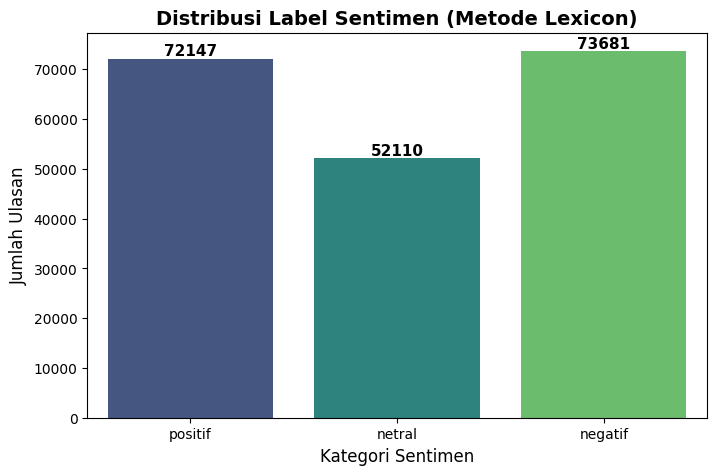

In [17]:
print("--- 1. Mengunduh Kamus Lexicon (Positif & Negatif) ---")
lexicon_positive = dict()
response_pos = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
if response_pos.status_code == 200:
    reader = csv.reader(StringIO(response_pos.text), delimiter=',')
    for row in reader:
        lexicon_positive[row[0]] = int(row[1])
else:
    print("Gagal mengunduh lexicon positif")

lexicon_negative = dict()
response_neg = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
if response_neg.status_code == 200:
    reader = csv.reader(StringIO(response_neg.text), delimiter=',')
    for row in reader:
        lexicon_negative[row[0]] = int(row[1])
else:
    print("Gagal mengunduh lexicon negatif")

print("✅ Kamus Lexicon berhasil dimuat!")

print("--- 2. Melakukan Pelabelan pada Dataset ---")
def sentiment_analysis_lexicon_indonesia(text):
    score = 0
    for word in text:
        if (word in lexicon_positive):
            score = score + lexicon_positive[word]
        if (word in lexicon_negative):
            score = score + lexicon_negative[word]

    polarity = ''
    if (score > 1):
        polarity = 'positif'
    elif (score < -1):
        polarity = 'negatif'
    else:
        polarity = 'netral'

    return score, polarity

results = df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
df['polarity_score'] = results[0]

df['label'] = results[1]

print("\n--- 3. Distribusi Hasil Pelabelan ---")
print(df['label'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label', palette='viridis', order=['positif', 'netral', 'negatif'])
plt.title("Distribusi Label Sentimen (Metode Lexicon)", fontsize=14, fontweight='bold')
plt.xlabel("Kategori Sentimen", fontsize=12)
plt.ylabel("Jumlah Ulasan", fontsize=12)

ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'bottom',
                fontsize=11, fontweight='bold')
plt.show()

##Data Balancing

In [18]:
print("--- Memulai proses Data Balancing (10K per kelas) ---")

target_jumlah = 10000

df_pos = df[df['label'] == 'positif']
df_neg = df[df['label'] == 'negatif']
df_net = df[df['label'] == 'netral']

df_pos_bal = df_pos.sample(n=target_jumlah, replace=True, random_state=42)
df_neg_bal = df_neg.sample(n=target_jumlah, replace=True, random_state=42)
df_net_bal = df_net.sample(n=target_jumlah, replace=True, random_state=42)

df_balanced = pd.concat([df_pos_bal, df_neg_bal, df_net_bal], ignore_index=True)

df_balanced = df_balanced.dropna(subset=['text_akhir', 'label'])
df_balanced = df_balanced[df_balanced['text_akhir'].str.strip() != ""]

df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"✅ BERHASIL! Total data seimbang: {len(df_balanced)} ulasan.")
print("\nDistribusi Akhir (Siap untuk Machine Learning):")
print(df_balanced['label'].value_counts())

--- Memulai proses Data Balancing (10K per kelas) ---
✅ BERHASIL! Total data seimbang: 29908 ulasan.

Distribusi Akhir (Siap untuk Machine Learning):
label
negatif    10000
positif    10000
netral      9908
Name: count, dtype: int64


##Visualisasi Distribusi

Menampilkan visualisasi distribusi data final yang sudah seimbang...


C:\Users\User\AppData\Local\Temp\ipykernel_3980\4191177814.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis', ax=ax[0])


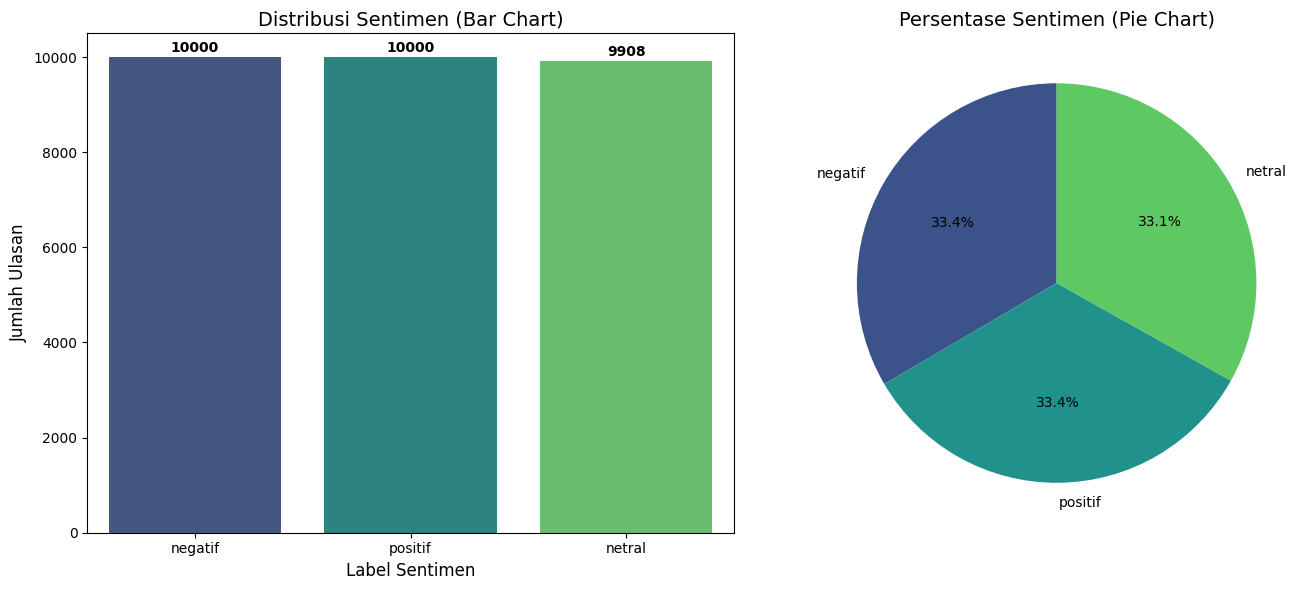

In [19]:
print("Menampilkan visualisasi distribusi data final yang sudah seimbang...")

label_counts = df_balanced['label'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis', ax=ax[0])
ax[0].set_title('Distribusi Sentimen (Bar Chart)', fontsize=14)
ax[0].set_xlabel('Label Sentimen', fontsize=12)
ax[0].set_ylabel('Jumlah Ulasan', fontsize=12)

for i, v in enumerate(label_counts.values):
    ax[0].text(i, v + 50, str(v), ha='center', va='bottom', fontweight='bold')

ax[1].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
          startangle=90, colors=sns.color_palette('viridis', len(label_counts)))
ax[1].set_title('Persentase Sentimen (Pie Chart)', fontsize=14)

plt.tight_layout()
plt.show()

##Export

In [24]:
import os
import time
from datetime import datetime

print("Memulai proses ekspor data final...")

# 1. Menyiapkan DataFrame
df_final = df_balanced[['text_akhir', 'label']].copy()
df_final = df_final.rename(columns={'text_akhir': 'ulasan'})
df_final = df_final.dropna(subset=['ulasan', 'label'])
df_final = df_final[df_final['ulasan'].str.strip() != ""]

# 2. Membuat Folder Khusus yang 100% Aman (Bebas Lock OneDrive)
nama_folder_aman = "Hasil_Export_Gojek"
if not os.path.exists(nama_folder_aman):
    os.makedirs(nama_folder_aman) # Otomatis membuat folder jika belum ada

# 3. Membuat nama file unik
nama_file = ('dataset_Gojek_siap_latih.csv')

# 4. Menggabungkan folder dan nama file
jalur_simpan = os.path.join(nama_folder_aman, nama_file)

# 5. Eksekusi Simpan
try:
    df_final.to_csv(jalur_simpan, index=False, encoding='utf-8')
    print(f"\n✅ BERHASIL DI-EXPORT!")
    print(f"File CSV kamu sekarang berada di dalam folder: '{nama_folder_aman}'")
    print(f"Lokasi Lengkap : {os.path.abspath(jalur_simpan)}")
    print(f"Total Baris    : {len(df_final)}")
except Exception as e:
    print(f"\n❌ Gagal menyimpan: {e}")

Memulai proses ekspor data final...

✅ BERHASIL DI-EXPORT!
File CSV kamu sekarang berada di dalam folder: 'Hasil_Export_Gojek'
Lokasi Lengkap : C:\Hasil_Export_Gojek\dataset_Gojek_siap_latih.csv
Total Baris    : 29908
